# Reto | Mercadotecnia telefónica con aprendizaje supervisado

#Guillermo Ortega Arzate

#Introducción
Los programas de telemarketing se han venido usando por las empresas durante años como una forma de comunicarse con clientes potenciales de manera directa por vía telefónica. En los últimos años el uso de las técnicas de inteligencia artificial ha permitido potencializar el impacto de estos programas de mercadotecnia.

Un banco ha lanzado **un nuevo plan de inversión** a largo plazo a través de un programa de telemarketing y desea saber que tan exitoso se puede considerar este programa utilizando técnicas de aprendizaje supervisado. El programa es lanzado a clientes del banco, por lo que este estudio ayudará a optimizar los esfuerzos al conocer las características de los clientes más **propensos a adquirir dicho plan de inversión**.

 En la presente actividad tu objetivo es predecir si el entrevistado adquirirá el plan de inversión bancario de acuerdo con varias características que se conocen de dicho cliente.

  ---
  This dataset is public available for research. The details are described in [Moro et al., 2011].
  Please include this citation if you plan to use this database:

  [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, GuimarÃ£es, Portugal, October, 2011. EUROSIS.

  Available at: [pdf] http://hdl.handle.net/1822/14838
                [bib] http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt
  ---


CARGA DE DATOS
Dataset cargado: 9000 filas, 17 columnas

Primeras filas:
   age            job  marital  education default  balance housing loan  \
0   31  self-employed  married   tertiary      no     2666      no   no   
1   29     unemployed   single    unknown      no     1584      no   no   
2   41    blue-collar  married  secondary      no     2152     yes   no   
3   50    blue-collar  married  secondary      no       84     yes   no   
4   40         admin.  married  secondary      no        0      no   no   

    contact  day month  duration  campaign  pdays  previous poutcome    y  
0  cellular   10   nov       318         2     97         6  success  yes  
1  cellular    6   sep       245         1     -1         0  unknown  yes  
2  cellular   17   nov       369         1     -1         0  unknown   no  
3  cellular   17   jul        18         8     -1         0  unknown   no  
4  cellular   28   jul       496         2    182        11  success  yes  

ANÁLISIS EXPLORATO

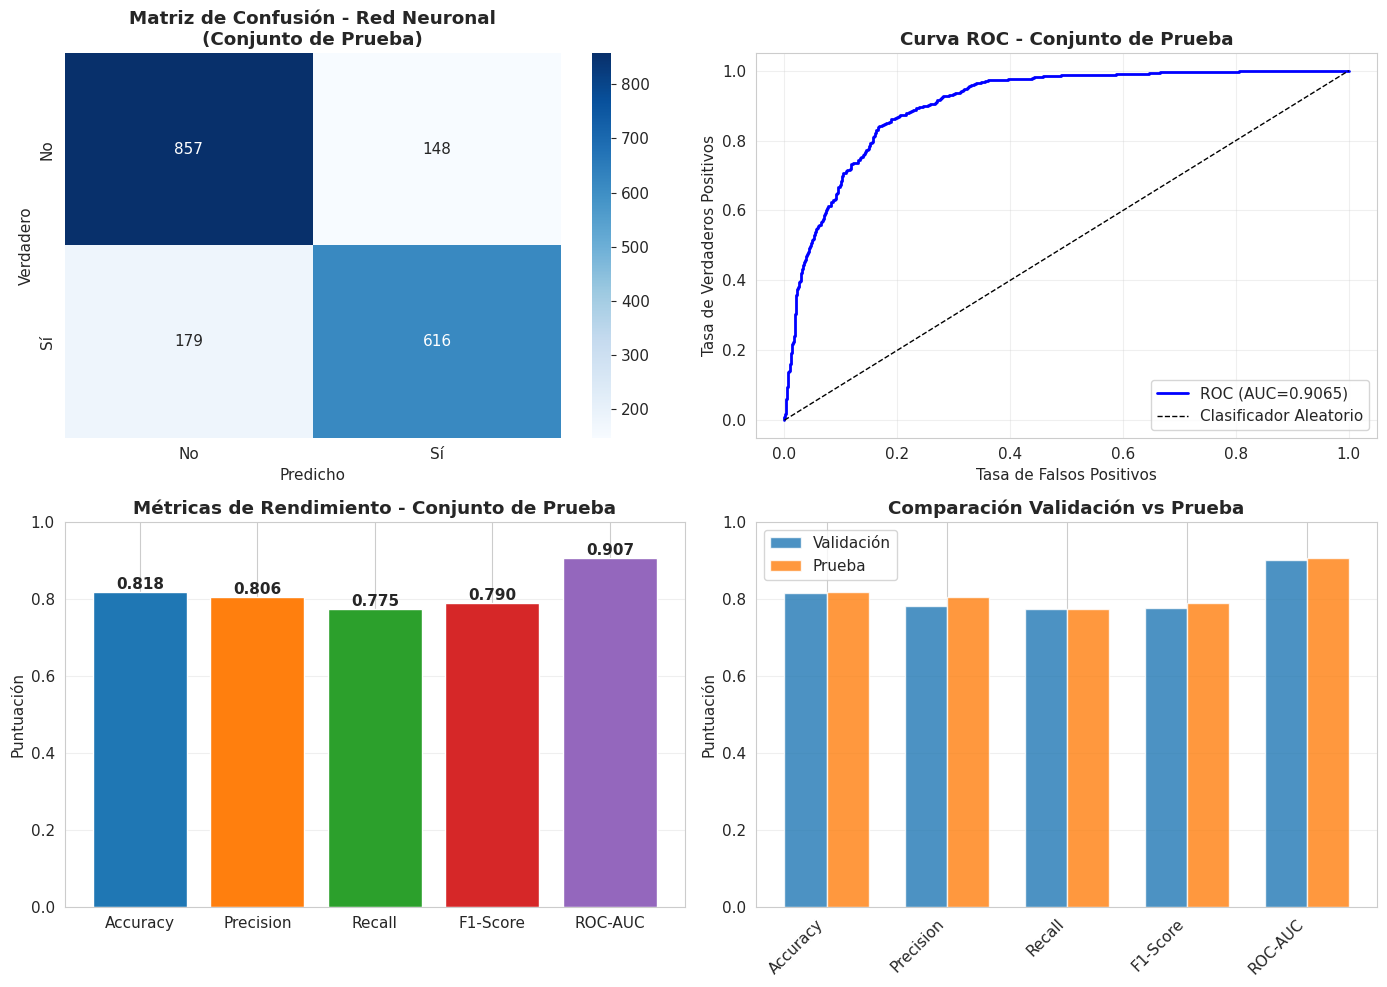


CONCLUSIONES

MODELO SELECCIONADO: Red Neuronal

- El dataset histórico indica que hay 42% de clientes que aceptarán la oferta.
- El modelo seleccionado predice con un Sí o un No en un porcenatje de 81.8333

RENDIMIENTO FINAL:
- Accuracy:   0.8183 (% de predicciones correctas)
- Precision:  0.8063 (de los "Sí" predichos, cuántos son correctos)
- Recall:     0.7748 (de los "Sí" reales, cuántos detectamos)
- F1-Score:   0.7903 (balance entre precision y recall)
- ROC-AUC:    0.9065 (probabilidad de acertar a un Sí o un No)

COMPARACIÓN CON VALIDACIÓN:
- No hay evidencia de SOBREAJUSTE (métricas validación ≈ métricas prueba)
  La desviación máxima encontrada fue de 0.03
  (ver gráfica de barras "Comparación Validación vs Pruebas")
- El modelo no está SUBENTRENADO, el porcentaje histórico de SI (aceptación) es de
  42.08% mientras que el modelo tiene una precisión de 80.63%

INTERPRETACIÓN PARA MARKETING:
- Por cada 100 clientes predichos como "aceptarán la oferta",
  81 realmente lo hará

In [10]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# =============================================================================
# 4. CARGA DE DATOS
# =============================================================================
print("\n" + "=" * 70)
print("CARGA DE DATOS")
print("=" * 70)

if not os.path.exists('bank_marketing_RETO_DS_AS.csv'):
    raise SystemExit("El archivo 'bank_marketing_RETO_DS_AS.csv' no existe")

data = pd.read_csv('bank_marketing_RETO_DS_AS.csv')

print(f"Dataset cargado: {data.shape[0]} filas, {data.shape[1]} columnas")
print(f"\nPrimeras filas:")
print(data.head())

# =============================================================================
# 5. ANÁLISIS EXPLORATORIO
# =============================================================================
print("\n" + "=" * 70)
print("ANÁLISIS EXPLORATORIO")
print("=" * 70)

print(f"\nTipos de datos:")
print(data.dtypes)

print(f"\nValores nulos:")
print(data.isnull().sum())

print(f"\nVariable objetivo (y):")
print(data['y'].value_counts())
# determinar porcentaje obervado, nuestro modelo deberá ser mejor que esto
porcentajeObservado = data['y'].value_counts(normalize=True)[1] * 100
print(f"  Porcentaje observado: {porcentajeObservado:.2f}%")

numericas_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas_cols = data.select_dtypes(include='object').columns.tolist()

print("\n" + "=" * 70)
print("Variables categóricas - valores únicos")
print("=" * 70)
for col in categoricas_cols:
    print(f"\n{col}: {data[col].nunique()} valores únicos")
    print(data[col].value_counts())

# =============================================================================
# 6.7.8 PREPROCESAMIENTO, TRANSFORMACIÓN
# =============================================================================
print("\n" + "=" * 70)
print("PREPROCESAMIENTO")
print("=" * 70)

# Conforme a los datos NO hay datos sin imputar
# Imputación
for col in numericas_cols:
    if data[col].isnull().sum() > 0:
        mediana = data[col].median()
        data[col].fillna(mediana, inplace=True)

for col in categoricas_cols:
    if data[col].isnull().sum() > 0:
        moda = data[col].mode()[0]
        data[col].fillna(moda, inplace=True)

print("No hay valores faltantes a imputar")

# Codificación
X_encoded = data.copy()


## se estuvieron haciendo pruebas con diferentes codificadores
## la primera prueba fue con OneHotEncoder y se generaban demasiadas variables
## la segunda prueba fue usando OrdinalEncoder con todas las categóricas pero
## desde el punto de vista teórico el Ordinal es cuando las variables tiene un orden
## y no es el caso de nuestros datos por lo que usa:
## Variables ordinales → OrdinalEncoder
## Variables nominales → LabelEncoder

# Conforme a la exploración se tiene que:
# las columnas 'default', 'housing', 'loan' son binarias (LabelEncoder):
print("\nCodificación de variables binarias: default, housing, loan.")

# las columnas job, marital, contact, poutcome son categóricas sin que sus valores reflejen un orden (LabelEncoder)
print("\nCodificación de variables categóricas sin orden: job, marital, contact, poutcome.")

# las columnas education, month son categóricas con orden (OrdinalEncoder)
# no es que un mes sea más relevante que otro pero los meses tienen un orden secuencial
print("\nCodificación de variables categóricas con orden: education, month")

# las variables age, day, duration, campaign, pdays, previous son numéricas discretas
print("\nVariables numéricas discretas: age, day, duration, campaign, pdays, previous")

# La variable balance es numéerica contínua
print("\nVariable numérica contínua: balance")

# codificar las binarias y categóricas sin orden
col_labelEncoder = ['job','marital','default','housing','loan','contact','poutcome','y']
le = LabelEncoder()
for col in col_labelEncoder:
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Mes como ordinal
# no es que un mes sea más relevante que otro pero los meses tienen un orden secuencial
mes_orden = ['jan', 'feb', 'mar', 'apr', 'may','jun','jul','aug','sep','oct','nov','dec']
oe_comp = OrdinalEncoder(categories=[mes_orden])
X_encoded['month'] = oe_comp.fit_transform(X_encoded[['month']]).astype(int)

# educacion con ordinal
education_orden = ['unknown','primary', 'secondary', 'tertiary']
oe_comp = OrdinalEncoder(categories=[education_orden])
X_encoded['education'] = oe_comp.fit_transform(X_encoded[['education']]).astype(int)


# pdays tiene valores de -1 y tiene sesgo, vamos a reemplzar los valores de -1 for 0
X_encoded['pdays'] = X_encoded['pdays'].replace(-1, 0)

# Balance tiene valores negativos y tiene sesgo, vamos a reemplazar los valores negativos con 0
X_encoded['balance'] = X_encoded['balance'].apply(lambda x: 0 if x < 0 else x)

# Transformaciones de sesgo
highly_skewed_features = ['balance','pdays','previous','campaign','duration','age']
X_transformed = X_encoded.copy()
for col in highly_skewed_features:
    X_transformed[col] = np.log1p(X_transformed[col])

X_encoded = X_transformed.copy()
print("Transformaciones aplicadas")

X = X_encoded.drop('y', axis=1)
y = X_encoded['y']

# =============================================================================
# 9. PARTICIÓN DE DATOS
# =============================================================================
print("\n" + "=" * 70)
print("PARTICIÓN DE DATOS")
print("=" * 70)

# División clara: 60% entrenamiento, 20% validación, 20% prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Entrenamiento:  {len(X_train):5d} ({len(X_train)/len(X)*100:.1f}%")
print(f"Validación:     {len(X_validation):5d} ({len(X_validation)/len(X)*100:.1f}%)")
print(f"Prueba:         {len(X_test):5d} ({len(X_test)/len(X)*100:.1f}%")

# =============================================================================
# NORMALIZACIÓN
# =============================================================================
print("\n" + "=" * 70)
print("ESCALADO DE CARACTERÍSTICAS")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("✅ Características escaladas con StandardScaler")
print(f"   Media en entrenamiento (primeras 3): {X_train_scaled.mean(axis=0)[:3]}")
print(f"   Desv. Est. en entrenamiento (primeras 3): {X_train_scaled.std(axis=0)[:3]}")

# =============================================================================
# 10. REGRESIÓN LOGÍSTICA
# =============================================================================
print("\n" + "=" * 70)
print("REGRESIÓN LOGÍSTICA")
print("=" * 70)


# Durante las pruebas se notó que el método newton-cg era muy tardado (más de 5 minutos
# en colab ambiente default y 10000 iteraciones).
# Se revisó la literatura y para el tamaño del dataset confirmaba lo que observamos
# y se recomendaba usar sólo lbfgs y liblinear en consideración de lo anterior y que los otros métodos
# tiene muy poco impacto en la exactitud. Tanto sag como saga están diseñados
# pata datasets 100x nuestro tamaño.
parameters = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

best_rl_score = 0
best_rl_params = {}
best_rl_model = None

print("\nBúsqueda de parámetros usando CONJUNTO DE VALIDACIÓN:")
print(f"{'C':>10} {'Penalty':>10} {'Solver':>15} {'Val Accuracy':>15}")
print("-" * 52)

for C in parameters['C']:
    for penalty in parameters['penalty']:
        for solver in parameters['solver']:
            try:
                model = LogisticRegression(
                    C=C,
                    penalty=penalty,
                    solver=solver,
                    max_iter=500,
                    random_state=42
                )
                model.fit(X_train_scaled, y_train)

                val_pred = model.predict(X_validation_scaled)
                val_acc = accuracy_score(y_validation, val_pred)

                print(f"{C:10.3f} {penalty:>10} {solver:>15} {val_acc:>15.4f}")

                if val_acc > best_rl_score:
                    best_rl_score = val_acc
                    best_rl_params = {'C': C, 'penalty': penalty, 'solver': solver}
                    best_rl_model = model

            except Exception as e:
                pass

print(f"\nMejores parámetros encontrados:")
print(f"  C: {best_rl_params['C']}")
print(f"  Penalty: {best_rl_params['penalty']}")
print(f"  Solver: {best_rl_params['solver']}")
print(f"  Score en validación: {best_rl_score:.4f}")

# Evaluación detallada en validación
y_pred_rl_val = best_rl_model.predict(X_validation_scaled)
y_pred_proba_rl_val = best_rl_model.predict_proba(X_validation_scaled)[:, 1]

print("\n📊 MÉTRICAS EN CONJUNTO DE VALIDACIÓN:")
print(f"  Accuracy:   {accuracy_score(y_validation, y_pred_rl_val):.4f} (% de predicciones correctas)")
print(f"  Precision:  {precision_score(y_validation, y_pred_rl_val):.4f} (de los 'Sí' predichos, cuántos son correctos)")
print(f"  Recall:     {recall_score(y_validation, y_pred_rl_val):.4f} (de los 'Sí' reales, cuántos detectamos)")
print(f"  F1-Score:   {f1_score(y_validation, y_pred_rl_val):.4f} (balance entre precision y recall)")
print(f"  ROC-AUC:    {roc_auc_score(y_validation, y_pred_proba_rl_val):.4f} (probabilidad de acertar a un Sí o un No)")

cm_rl_val = confusion_matrix(y_validation, y_pred_rl_val)
print(f"\n🔲 Matriz de confusión (validación):")
print(cm_rl_val)

# =============================================================================
# 11. RED NEURONAL
# =============================================================================
print("\n" + "=" * 70)
print("RED NEURONAL")
print("=" * 70)

# al principio se probó con aquitecturas de redes de dos capas ocultas del mismo
# tamaño, pero la cantidad de neuronas variaba mucho por ejemplo entre 16 y 26
# dependiendo de la semilla que seleccionara.
# se revisó el siguiente documento https://www.heatonresearch.com/2017/06/01/hidden-layers.html
# y conforme a sus recomendaciones se probó con las siguientes arquitecturas.
# El 16 sale de que debe ser menor de la cantidad de entradas (17) + salida
# no se recomienda más de dos capas para la complejidad del problema.
# La primera capa aprende características, segunda capa patrones
hidden_layers_to_try = [(16,), (16,16), (32,16), (64,32), (128,64)]
best_nn_score = 0
best_nn_params = {}
best_nn_model = None

print("\nBúsqueda de parámetros usando CONJUNTO DE VALIDACIÓN:")
print(f"{'Hidden Layers':>30} {'Val Accuracy':>15} {'Iteraciones':>15}")
print("-" * 62)

for hidden_layers in hidden_layers_to_try:
    try:
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            max_iter=500,                      # Reducido para evitar sobreajuste
            alpha=0.0001,                      # Regularización L2 (valor default)
            batch_size=32,                     # default es 100 pero literatura indica empezar en 32, 64
            learning_rate_init=0.001,          # recomendado por la literatura
            early_stopping=True,               # detenerse cuando no mejora validación
            validation_fraction=0.2,           # usar 20% del entrenamiento para validar (cuando early_stopping = True)
            n_iter_no_change=20,               # previene sobreajuste, iteraciones máximas sin superar tolerancia a mejora
            random_state=42,                   # semilla para reproducir los cálculos, 42 es usado en los ejemplos
            verbose=0                          # no mandar actualizaciones a la consola (default)
        )

        model.fit(X_train_scaled, y_train)

        val_pred = model.predict(X_validation_scaled)
        val_acc = accuracy_score(y_validation, val_pred)

        print(f"{str(hidden_layers):>30} {val_acc:>15.4f} {model.n_iter_:>15}")

        if val_acc > best_nn_score:
            best_nn_score = val_acc
            best_nn_params = {'hidden_layers': hidden_layers}
            best_nn_model = model

    except Exception as e:
        print(f"Error con {hidden_layers}: {e}")

print(f"\nMejores parámetros encontrados:")
print(f"  Hidden layers: {best_nn_params['hidden_layers']}")
print(f"  Score en validación: {best_nn_score:.4f}")

# Evaluación detallada en validación
y_pred_nn_val = best_nn_model.predict(X_validation_scaled)
y_pred_proba_nn_val = best_nn_model.predict_proba(X_validation_scaled)[:, 1]

print("\n📊 MÉTRICAS EN CONJUNTO DE VALIDACIÓN:")
print(f"  Accuracy:   {accuracy_score(y_validation, y_pred_nn_val):.4f} (% de predicciones correctas)")
print(f"  Precision:  {precision_score(y_validation, y_pred_nn_val):.4f} (de los 'Sí' predichos, cuántos son correctos)")
print(f"  Recall:     {recall_score(y_validation, y_pred_nn_val):.4f} (de los 'Sí' reales, cuántos detectamos)")
print(f"  F1-Score:   {f1_score(y_validation, y_pred_nn_val):.4f} (balance entre precision y recall)")
print(f"  ROC-AUC:    {roc_auc_score(y_validation, y_pred_proba_nn_val):.4f} (probabilidad de acertar a un Sí o un No)")

cm_nn_val = confusion_matrix(y_validation, y_pred_nn_val)
print(f"\n🔲 Matriz de confusión (validación):")
print(cm_nn_val)

# =============================================================================
# 12. COMPARACIÓN Y SELECCIÓN DEL MEJOR MODELO
# =============================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)

print(f"\nAccuracy en VALIDACIÓN:")
print(f"  Regresión Logística: {best_rl_score:.4f}")
print(f"  Red Neuronal:        {best_nn_score:.4f}")

if best_rl_score > best_nn_score:
    print("\n✅ SELECCIONADO: Regresión Logística")
    best_model = best_rl_model
    best_model_name = "Regresión Logística"
    best_metrics_val = {
        'accuracy': accuracy_score(y_validation, y_pred_rl_val),
        'precision': precision_score(y_validation, y_pred_rl_val),
        'recall': recall_score(y_validation, y_pred_rl_val),
        'f1': f1_score(y_validation, y_pred_rl_val),
        'roc_auc': roc_auc_score(y_validation, y_pred_proba_rl_val)
    }
else:
    print("\n✅ SELECCIONADO: Red Neuronal")
    best_model = best_nn_model
    best_model_name = "Red Neuronal"
    best_metrics_val = {
        'accuracy': accuracy_score(y_validation, y_pred_nn_val),
        'precision': precision_score(y_validation, y_pred_nn_val),
        'recall': recall_score(y_validation, y_pred_nn_val),
        'f1': f1_score(y_validation, y_pred_nn_val),
        'roc_auc': roc_auc_score(y_validation, y_pred_proba_nn_val)
    }

# =============================================================================
# EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA
# =============================================================================
print("\n" + "=" * 70)
print("EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA")
print("=" * 70)

print(f"\nModelo seleccionado: {best_model_name}\n")

y_pred_test = best_model.predict(X_test_scaled)
y_pred_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test),
    'recall': recall_score(y_test, y_pred_test),
    'f1': f1_score(y_test, y_pred_test),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_test)
}

print("📊 MÉTRICAS FINALES EN CONJUNTO DE PRUEBA:")
print(f"  Accuracy:   {test_metrics['accuracy']:.4f} (% de predicciones correctas)")
print(f"  Precision:  {test_metrics['precision']:.4f} (de los 'Sí' predichos, cuántos son correctos)")
print(f"  Recall:     {test_metrics['recall']:.4f} (de los 'Sí' reales, cuántos detectamos)")
print(f"  F1-Score:   {test_metrics['f1']:.4f} (balance entre precision y recall)")
print(f"  ROC-AUC:    {test_metrics['roc_auc']:.4f} (probabilidad de acertar a un Sí o un No)")

cm_test = confusion_matrix(y_test, y_pred_test)
print(f"\n🔲 Matriz de confusión (PRUEBA):")
print(cm_test)

# Análisis de matriz de confusión
tn, fp, fn, tp = cm_test.ravel()
print(f"\nDesglose:")
print(f"  Verdaderos Positivos (TP):  {tp}")
print(f"  Verdaderos Negativos (TN):  {tn}")
print(f"  Falsos Positivos (FP):      {fp}")
print(f"  Falsos Negativos (FN):      {fn}")

# =============================================================================
# VISUALIZACIONES
# =============================================================================
print("\n" + "=" * 70)
print("VISUALIZACIONES")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Matriz de confusión
ax = axes[0, 0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
ax.set_title(f'Matriz de Confusión - {best_model_name}\n(Conjunto de Prueba)', fontweight='bold')
ax.set_ylabel('Verdadero')
ax.set_xlabel('Predicho')

# Curva ROC
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
ax.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC={test_metrics["roc_auc"]:.4f})', color='blue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC - Conjunto de Prueba', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Comparación de métricas
ax = axes[1, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [test_metrics['accuracy'], test_metrics['precision'],
                  test_metrics['recall'], test_metrics['f1'], test_metrics['roc_auc']]
bars = ax.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax.set_ylabel('Puntuación')
ax.set_title('Métricas de Rendimiento - Conjunto de Prueba', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')
# Añadir valores en las barras
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Comparación validación vs prueba
ax = axes[1, 1]
x_pos = np.arange(len(metrics_names))
width = 0.35
val_values = [best_metrics_val['accuracy'], best_metrics_val['precision'],
              best_metrics_val['recall'], best_metrics_val['f1'], best_metrics_val['roc_auc']]
ax.bar(x_pos - width/2, val_values, width, label='Validación', alpha=0.8)
ax.bar(x_pos + width/2, metrics_values, width, label='Prueba', alpha=0.8)
ax.set_ylabel('Puntuación')
ax.set_title('Comparación Validación vs Prueba', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# obtener la máxima variación entre pruebas y validación
max_diff = max(abs(np.array(val_values) - np.array(metrics_values)))

plt.tight_layout()
plt.savefig('resultados_finales.png',
            dpi=150, bbox_inches='tight')
print("\n✅ Gráficas guardadas en 'resultados_finales.png'")
plt.show()

# =============================================================================
# 13. CONCLUSIONES
# =============================================================================
print("\n" + "=" * 70)
print("CONCLUSIONES")
print("=" * 70)

print(f"""
MODELO SELECCIONADO: {best_model_name}

- El dataset histórico indica que hay 42% de clientes que aceptarán la oferta.
- El modelo seleccionado predice con un Sí o un No en un porcenatje de {test_metrics['accuracy']*100:.4f}

RENDIMIENTO FINAL:
- Accuracy:   {test_metrics['accuracy']:.4f} (% de predicciones correctas)
- Precision:  {test_metrics['precision']:.4f} (de los "Sí" predichos, cuántos son correctos)
- Recall:     {test_metrics['recall']:.4f} (de los "Sí" reales, cuántos detectamos)
- F1-Score:   {test_metrics['f1']:.4f} (balance entre precision y recall)
- ROC-AUC:    {test_metrics['roc_auc']:.4f} (probabilidad de acertar a un Sí o un No)

COMPARACIÓN CON VALIDACIÓN:
- No hay evidencia de SOBREAJUSTE (métricas validación ≈ métricas prueba)
  La desviación máxima encontrada fue de {max_diff:.2f}
  (ver gráfica de barras "Comparación Validación vs Pruebas")
- El modelo no está SUBENTRENADO, el porcentaje histórico de SI (aceptación) es de
  {porcentajeObservado:.2f}% mientras que el modelo tiene una precisión de {test_metrics['precision']*100:.2f}%

INTERPRETACIÓN PARA MARKETING:
- Por cada 100 clientes predichos como "aceptarán la oferta",
  {test_metrics['precision']*100:.0f} realmente lo harán.

- De los clientes que realmente aceptarían, el modelo detecta
  el {test_metrics['recall']*100:.0f}% de ellos.

RECOMENDACIONES:
1. El modelo puede usarse para identificar clientes con mayor probabilidad
   de aceptar ofertas de mercadotecnia telefónica.

2. La métrica de {('Recall' if test_metrics['recall'] < test_metrics['precision'] else 'Precision')} es más crítica
   dependiendo del objetivo (detectar máximo de clientes vs. precisión máxima).

3. Se recomienda usar el ROC-AUC como métrica principal para
   comparación con futuros modelos, puesto que representa
   la probabilidad de que el modelo ordene correctamente
   un cliente que dice "Sí" y otro que dice "No", elegidos al azar
""")
